In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

df = pd.read_csv(r"C:\Users\Girish\Downloads\web_traffic_analytics_v2.csv")
print(df.shape)
print(df.head())
print(df.isna().sum())    
print(df.SessionID.duplicated().sum())  

(900, 12)
     SessionID        Date LandingPage          Source Campaign  \
0  SESS-500001  2026-02-15           /           Email     none   
1  SESS-500002  2026-06-03           /          Direct     none   
2  SESS-500003  2026-04-14   /register  Google Organic  starter   
3  SESS-500004  2026-03-31   /register           Email   campus   
4  SESS-500005  2026-04-24   /programs          Direct     none   

  DeviceCategory       Region  SessionDurationSec  PageViews  \
0         Mobile        Delhi                 243          3   
1         Mobile    Karnataka                 268          4   
2        Desktop    Telangana                 360          3   
3        Desktop  Maharashtra                 282          5   
4         Mobile   Tamil Nadu                 232          2   

  StartedRegistration Registered Bounced  
0                 Yes         No      No  
1                  No         No      No  
2                 Yes        Yes      No  
3                 Yes        Y

In [5]:
for c in ['StartedRegistration', 'Registered', 'Bounced']:
    df[c] = df[c] == 'Yes'    

df['Month'] = pd.to_datetime(df.Date).dt.strftime('%b')

In [4]:
print(df[['StartedRegistration', 'Registered', 'Bounced', 'Month']].head())

   StartedRegistration  Registered  Bounced Month
0                 True       False    False   Feb
1                False       False    False   Jun
2                 True        True    False   Apr
3                 True        True    False   Mar
4                False       False    False   Apr


In [6]:
N = len(df)
bounce_rate = df.Bounced.mean() * 100
avg_duration = df.SessionDurationSec.mean()
avg_pv = df.PageViews.mean()
conv_rate = df.Registered.mean() * 100

print(f"Sessions: {N}")
print(f"Bounce rate: {bounce_rate:.1f}%")
print(f"Avg duration: {avg_duration:.0f} sec")
print(f"Pageviews/session: {avg_pv:.2f}")
print(f"Conversion: {conv_rate:.1f}%")

Sessions: 900
Bounce rate: 0.0%
Avg duration: 243 sec
Pageviews/session: 3.45
Conversion: 0.0%


In [7]:
df = pd.read_csv(r"C:\Users\Girish\Downloads\web_traffic_analytics_v2.csv")

for c in ['StartedRegistration', 'Registered', 'Bounced']:
    df[c] = df[c] == 'Yes'

df['Month'] = pd.to_datetime(df.Date).dt.strftime('%b')

print(df.Bounced.sum(), df.Registered.sum()) 

44 166


In [8]:
N = len(df)
bounce_rate = df.Bounced.mean() * 100
avg_duration = df.SessionDurationSec.mean()
avg_pv = df.PageViews.mean()
conv_rate = df.Registered.mean() * 100

print(f"Sessions: {N}")
print(f"Bounce rate: {bounce_rate:.1f}%")
print(f"Avg duration: {avg_duration:.0f} sec")
print(f"Pageviews/session: {avg_pv:.2f}")
print(f"Conversion: {conv_rate:.1f}%")

Sessions: 900
Bounce rate: 4.9%
Avg duration: 243 sec
Pageviews/session: 3.45
Conversion: 18.4%


In [9]:
def summarize(col):
    a = df.groupby(col).agg(
        sessions=('SessionID', 'count'),
        bounce=('Bounced', 'mean'),
        duration=('SessionDurationSec', 'mean'),
        pageviews=('PageViews', 'mean'),
        started=('StartedRegistration', 'sum'),
        registered=('Registered', 'sum'))
    a['bounce'] *= 100
    a['conv'] = a.registered / a.sessions * 100          
    a['start_to_reg'] = a.registered / a.started * 100  
    return a.round(2)

by_source  = summarize('Source')
by_landing = summarize('LandingPage')
by_device  = summarize('DeviceCategory')
by_month   = summarize('Month').reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug'])

print(by_source.sort_values('conv', ascending=False))
print(by_device)
print(by_month)

                sessions  bounce  duration  pageviews  started  registered  \
Source                                                                       
Instagram             93    4.30    263.78       3.74       37          22   
Email                127    4.72    243.27       3.51       41          30   
Referral              85    7.06    222.36       3.29       27          16   
Direct               207    5.80    228.16       3.32       62          36   
LinkedIn             123    6.50    238.72       3.38       33          21   
Google Organic       265    3.02    257.42       3.51       77          41   

                 conv  start_to_reg  
Source                               
Instagram       23.66         59.46  
Email           23.62         73.17  
Referral        18.82         59.26  
Direct          17.39         58.06  
LinkedIn        17.07         63.64  
Google Organic  15.47         53.25  
                sessions  bounce  duration  pageviews  started  registe

In [10]:
mapping = {'Google Organic': 'Organic', 'Direct': 'Direct',
           'Instagram': 'Social', 'LinkedIn': 'Social',
           'Email': 'Email', 'Referral': 'Referral'}
df['Channel'] = df.Source.map(mapping)

by_channel = summarize('Channel')
print(by_channel.sort_values('conv', ascending=False))

          sessions  bounce  duration  pageviews  started  registered   conv  \
Channel                                                                       
Email          127    4.72    243.27       3.51       41          30  23.62   
Social         216    5.56    249.51       3.54       70          43  19.91   
Referral        85    7.06    222.36       3.29       27          16  18.82   
Direct         207    5.80    228.16       3.32       62          36  17.39   
Organic        265    3.02    257.42       3.51       77          41  15.47   

          start_to_reg  
Channel                 
Email            73.17  
Social           61.43  
Referral         59.26  
Direct           58.06  
Organic          53.25  


In [11]:
funnel = {
    'Sessions': N,
    'Engaged (not bounced)': (~df.Bounced).sum(),
    'Started registration': df.StartedRegistration.sum(),
    'Registered': df.Registered.sum()}

for k, v in funnel.items():
    print(f"{k}: {v} ({v/N*100:.0f}%)")

print("\nStarted -> Registered:", round(df.Registered.sum() / df.StartedRegistration.sum() * 100), "%")

by_landing['drop_off'] = 100 - by_landing.conv
print(by_landing.sort_values('drop_off', ascending=False)[['sessions', 'bounce', 'drop_off', 'start_to_reg']])

Sessions: 900 (100%)
Engaged (not bounced): 856 (95%)
Started registration: 277 (31%)
Registered: 166 (18%)

Started -> Registered: 60 %
             sessions  bounce  drop_off  start_to_reg
LandingPage                                          
/                 161    7.45     86.96         46.67
/programs         161    3.11     81.99         59.18
/faq              144    3.47     81.94         59.09
/register         151    5.30     80.79         69.05
/verify           139    7.91     79.86         58.33
/login            144    2.08     77.08         67.35


(900, 12) | missing: 0 | duplicates: 0
Sessions: 900 | Bounce: 4.9% | Duration: 243s | Pages/session: 3.45 | Conversion: 18.4%

           sessions  bounce  duration  pageviews  started  registered   conv  \
Channel                                                                       
Email          127    4.72    243.27       3.51       41          30  23.62   
Social         216    5.56    249.51       3.54       70          43  19.91   
Referral        85    7.06    222.36       3.29       27          16  18.82   
Direct         207    5.80    228.16       3.32       62          36  17.39   
Organic        265    3.02    257.42       3.51       77          41  15.47   

          start_to_reg  
Channel                 
Email            73.17  
Social           61.43  
Referral         59.26  
Direct           58.06  
Organic          53.25  

              sessions  bounce  drop_off  start_to_reg
LandingPage                                          
/                 161    7.45   

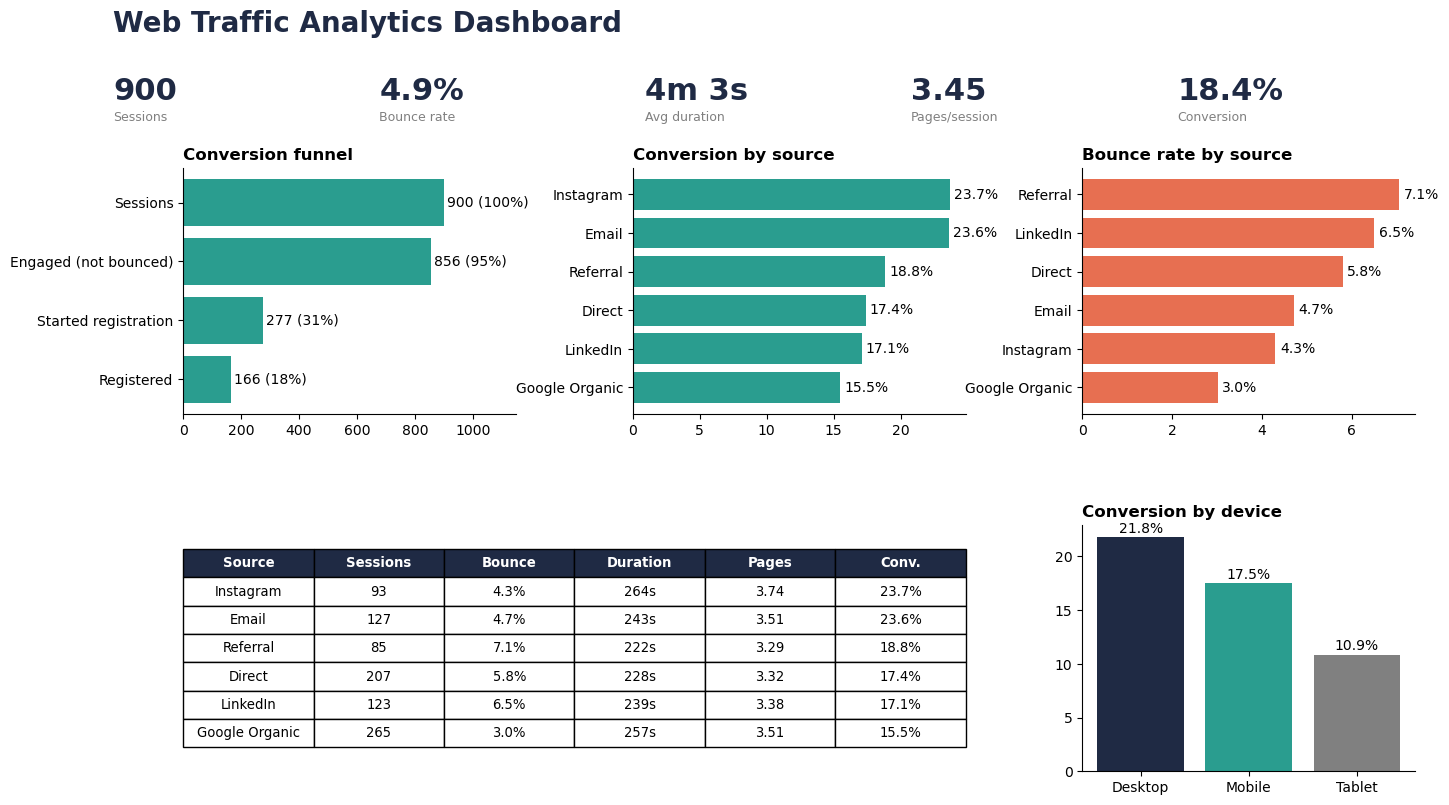

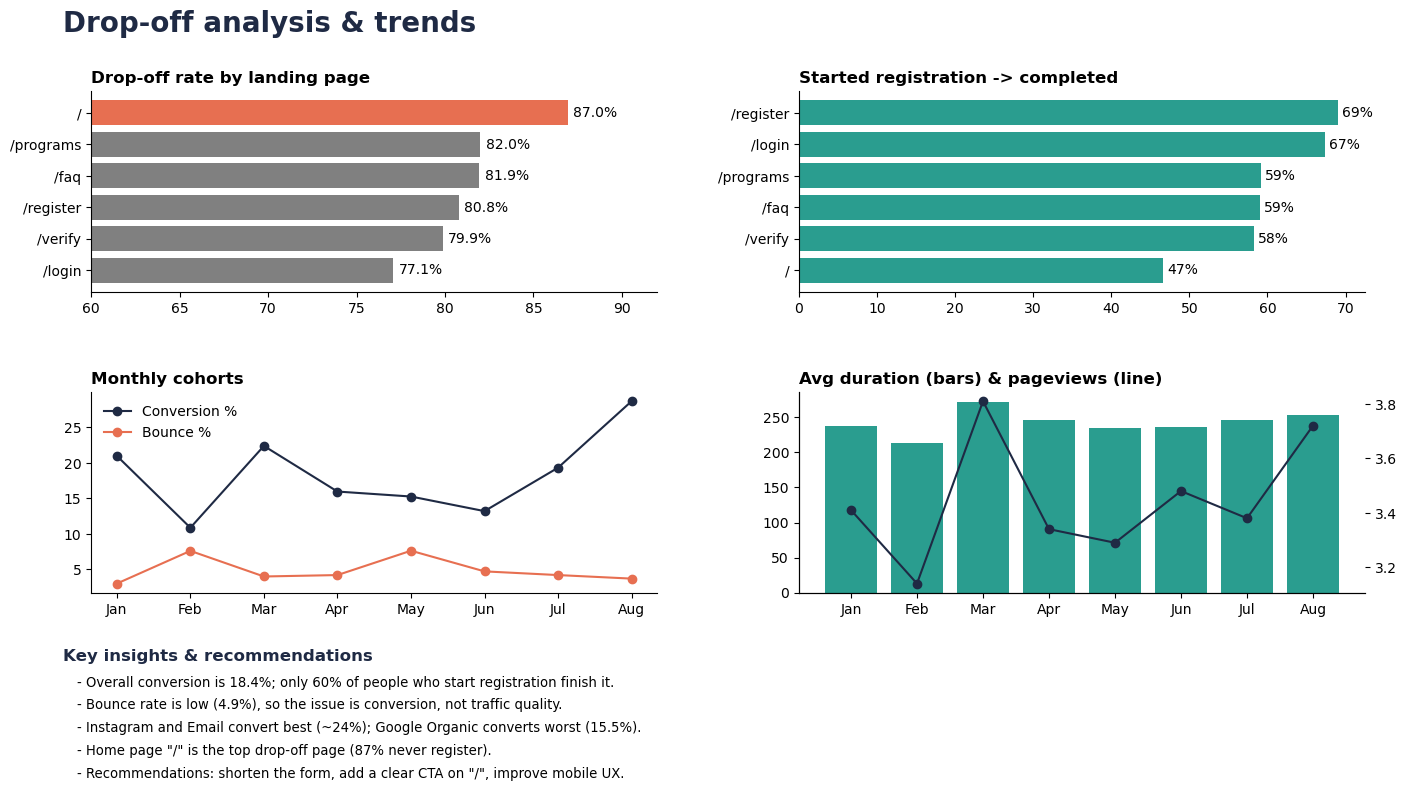


Saved: Web_Traffic_Analytics_Dashboard.pdf in Downloads


In [14]:
# ============ Web Traffic Analytics - Complete Code ============
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

# ---------- STEP 1: Load data ----------
df = pd.read_csv(r"C:\Users\Girish\Downloads\web_traffic_analytics_v2.csv")
print(df.shape, "| missing:", df.isna().sum().sum(), "| duplicates:", df.SessionID.duplicated().sum())

# ---------- STEP 2: Clean ----------
for c in ['StartedRegistration', 'Registered', 'Bounced']:
    df[c] = df[c] == 'Yes'
df['Month'] = pd.to_datetime(df.Date).dt.strftime('%b')

# ---------- STEP 3: Overall metrics ----------
N = len(df)
bounce_rate = df.Bounced.mean() * 100
avg_duration = df.SessionDurationSec.mean()
avg_pv = df.PageViews.mean()
conv_rate = df.Registered.mean() * 100
print(f"Sessions: {N} | Bounce: {bounce_rate:.1f}% | Duration: {avg_duration:.0f}s | "
      f"Pages/session: {avg_pv:.2f} | Conversion: {conv_rate:.1f}%")

# ---------- STEP 4: Group-by function ----------
def summarize(col):
    a = df.groupby(col).agg(
        sessions=('SessionID', 'count'),
        bounce=('Bounced', 'mean'),
        duration=('SessionDurationSec', 'mean'),
        pageviews=('PageViews', 'mean'),
        started=('StartedRegistration', 'sum'),
        registered=('Registered', 'sum'))
    a['bounce'] *= 100
    a['conv'] = a.registered / a.sessions * 100
    a['start_to_reg'] = a.registered / a.started * 100
    return a.round(2)

by_source  = summarize('Source')
by_landing = summarize('LandingPage')
by_device  = summarize('DeviceCategory')
by_month   = summarize('Month').reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug'])

# ---------- STEP 5: Channel grouping ----------
mapping = {'Google Organic': 'Organic', 'Direct': 'Direct',
           'Instagram': 'Social', 'LinkedIn': 'Social',
           'Email': 'Email', 'Referral': 'Referral'}
df['Channel'] = df.Source.map(mapping)
by_channel = summarize('Channel')
print("\n", by_channel.sort_values('conv', ascending=False))

# ---------- STEP 6: Funnel & drop-off ----------
funnel = {
    'Sessions': N,
    'Engaged (not bounced)': (~df.Bounced).sum(),
    'Started registration': df.StartedRegistration.sum(),
    'Registered': df.Registered.sum()}
by_landing['drop_off'] = 100 - by_landing.conv
print("\n", by_landing.sort_values('drop_off', ascending=False)[['sessions','bounce','drop_off','start_to_reg']])

# ---------- STEP 7: Dashboard (shows in notebook + saves PDF) ----------
NAVY, TEAL, RED = '#1f2a44', '#2a9d8f', '#e76f51'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

with PdfPages(r"C:\Users\Girish\Downloads\Web_Traffic_Analytics_Dashboard.pdf") as pdf:

    # ----- PAGE 1 -----
    fig = plt.figure(figsize=(14, 8.5))
    fig.text(0.04, 0.94, 'Web Traffic Analytics Dashboard', fontsize=20, fontweight='bold', color=NAVY)
    kpis = [('Sessions', f'{N}'), ('Bounce rate', f'{bounce_rate:.1f}%'),
            ('Avg duration', f'{int(avg_duration//60)}m {int(avg_duration%60)}s'),
            ('Pages/session', f'{avg_pv:.2f}'), ('Conversion', f'{conv_rate:.1f}%')]
    for i, (label, val) in enumerate(kpis):
        fig.text(0.04 + i*0.19, 0.86, val, fontsize=22, fontweight='bold', color=NAVY)
        fig.text(0.04 + i*0.19, 0.835, label, fontsize=9, color='grey')

    gs = fig.add_gridspec(2, 3, left=0.09, right=0.97, top=0.78, bottom=0.07, hspace=0.45, wspace=0.35)

    ax = fig.add_subplot(gs[0, 0])
    labels, vals = list(funnel.keys())[::-1], list(funnel.values())[::-1]
    ax.barh(labels, vals, color=TEAL)
    for i, v in enumerate(vals):
        ax.text(v + 10, i, f'{v} ({v/N*100:.0f}%)', va='center')
    ax.set_xlim(0, 1150); ax.set_title('Conversion funnel', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[0, 1])
    s = by_source.sort_values('conv')
    ax.barh(s.index, s.conv, color=TEAL)
    for i, v in enumerate(s.conv):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    ax.set_title('Conversion by source', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[0, 2])
    s = by_source.sort_values('bounce')
    ax.barh(s.index, s.bounce, color=RED)
    for i, v in enumerate(s.bounce):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center')
    ax.set_title('Bounce rate by source', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[1, 2])
    ax.bar(by_device.index, by_device.conv, color=[NAVY, TEAL, 'grey'])
    for i, v in enumerate(by_device.conv):
        ax.text(i, v + 0.4, f'{v:.1f}%', ha='center')
    ax.set_title('Conversion by device', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[1, :2]); ax.axis('off')
    t = by_source.sort_values('conv', ascending=False)
    rows = [[i, int(r.sessions), f'{r.bounce:.1f}%', f'{r.duration:.0f}s',
             f'{r.pageviews:.2f}', f'{r.conv:.1f}%'] for i, r in t.iterrows()]
    tb = ax.table(cellText=rows, colLabels=['Source','Sessions','Bounce','Duration','Pages','Conv.'],
                  loc='center', cellLoc='center')
    tb.auto_set_font_size(False); tb.set_fontsize(9.5); tb.scale(1, 1.7)
    for (r, c), cell in tb.get_celld().items():
        if r == 0:
            cell.set_facecolor(NAVY); cell.set_text_props(color='white', fontweight='bold')
    pdf.savefig(fig); plt.show(); plt.close(fig)

    # ----- PAGE 2 -----
    fig = plt.figure(figsize=(14, 8.5))
    fig.text(0.04, 0.94, 'Drop-off analysis & trends', fontsize=20, fontweight='bold', color=NAVY)
    gs = fig.add_gridspec(2, 2, left=0.06, right=0.97, top=0.87, bottom=0.28, hspace=0.5, wspace=0.25)

    ax = fig.add_subplot(gs[0, 0])
    l = by_landing.sort_values('drop_off')
    ax.barh(l.index, l.drop_off, color=['grey']*5 + [RED])
    for i, v in enumerate(l.drop_off):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    ax.set_xlim(60, 92); ax.set_title('Drop-off rate by landing page', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[0, 1])
    l = by_landing.sort_values('start_to_reg')
    ax.barh(l.index, l.start_to_reg, color=TEAL)
    for i, v in enumerate(l.start_to_reg):
        ax.text(v + 0.5, i, f'{v:.0f}%', va='center')
    ax.set_title('Started registration -> completed', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[1, 0])
    ax.plot(by_month.index, by_month.conv, marker='o', color=NAVY, label='Conversion %')
    ax.plot(by_month.index, by_month.bounce, marker='o', color=RED, label='Bounce %')
    ax.legend(frameon=False); ax.set_title('Monthly cohorts', loc='left', fontweight='bold')

    ax = fig.add_subplot(gs[1, 1])
    ax.bar(by_month.index, by_month.duration, color=TEAL)
    ax2 = ax.twinx(); ax2.plot(by_month.index, by_month.pageviews, color=NAVY, marker='o')
    ax.set_title('Avg duration (bars) & pageviews (line)', loc='left', fontweight='bold')

    insights = [
        f'Overall conversion is {conv_rate:.1f}%; only 60% of people who start registration finish it.',
        f'Bounce rate is low ({bounce_rate:.1f}%), so the issue is conversion, not traffic quality.',
        'Instagram and Email convert best (~24%); Google Organic converts worst (15.5%).',
        'Home page "/" is the top drop-off page (87% never register).',
        'Recommendations: shorten the form, add a clear CTA on "/", improve mobile UX.']
    fig.text(0.04, 0.2, 'Key insights & recommendations', fontsize=12, fontweight='bold', color=NAVY)
    for i, t in enumerate(insights):
        fig.text(0.05, 0.17 - i*0.027, '- ' + t, fontsize=9.5)
    pdf.savefig(fig); plt.show(); plt.close(fig)

print('\nSaved: Web_Traffic_Analytics_Dashboard.pdf in Downloads')